<a href="https://colab.research.google.com/github/islombek-cs/Computer-Vision-Labs/blob/main/CV_Lab_5_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name:** Islombek Abdurakhmanov  
**ID:** 221236  
**Shared Colab Link:** https://colab.research.google.com/drive/1778MVMZB77_SaBNytpbcuXnRXtYh2dDu?usp=sharing

# Lab 5-6 — Multi Layer Perceptron and Convolution Neural Netrok


**Course:** 4-COV-10-413 · Computer Vision  
**Runtime:** Google Colab  
**Policy:** You must implement core functions yourself. Using `pytorch` is allowed **only in the comparison cells**. Copy–pasting complete solutions from the web is not allowed.



#Loading MNIST DATA

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


batch_size = 64

# MNIST Dataset
train_dataset = datasets.MNIST(root='./data', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transforms.ToTensor())

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)




100%|██████████| 9.91M/9.91M [00:00<00:00, 20.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 507kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.86MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 16.7MB/s]


#BUILDING AND TRAINING MLP

In [2]:
# Hyperparameters
input_size = 784  # 28x28 images
hidden_size = 500
num_classes = 10
num_epochs = 2
learning_rate = 0.001

# MLP Model
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x.view(-1, input_size))
        out = self.relu(out)
        out = self.fc2(out)
        return out

modelMLP = MLP(input_size, hidden_size, num_classes)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelMLP.parameters(), lr=learning_rate)

# Train the Model
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        # Forward + Backward + Optimize
        optimizer.zero_grad()
        outputs = modelMLP(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        if (i+1) % batch_size == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

# Test the Model
modelMLP.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        outputs = modelMLP(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f'Accuracy of the model on the 10000 test images: {100 * correct / total} %')

Epoch [1/2], Step [64/938], Loss: 0.4262
Epoch [1/2], Step [128/938], Loss: 0.4581
Epoch [1/2], Step [192/938], Loss: 0.2252
Epoch [1/2], Step [256/938], Loss: 0.1702
Epoch [1/2], Step [320/938], Loss: 0.1100
Epoch [1/2], Step [384/938], Loss: 0.2793
Epoch [1/2], Step [448/938], Loss: 0.2580
Epoch [1/2], Step [512/938], Loss: 0.1041
Epoch [1/2], Step [576/938], Loss: 0.1245
Epoch [1/2], Step [640/938], Loss: 0.1621
Epoch [1/2], Step [704/938], Loss: 0.0748
Epoch [1/2], Step [768/938], Loss: 0.0517
Epoch [1/2], Step [832/938], Loss: 0.0522
Epoch [1/2], Step [896/938], Loss: 0.0810
Epoch [2/2], Step [64/938], Loss: 0.1169
Epoch [2/2], Step [128/938], Loss: 0.0482
Epoch [2/2], Step [192/938], Loss: 0.0609
Epoch [2/2], Step [256/938], Loss: 0.2190
Epoch [2/2], Step [320/938], Loss: 0.0293
Epoch [2/2], Step [384/938], Loss: 0.0648
Epoch [2/2], Step [448/938], Loss: 0.0305
Epoch [2/2], Step [512/938], Loss: 0.1602
Epoch [2/2], Step [576/938], Loss: 0.1495
Epoch [2/2], Step [640/938], Loss: 0

#Results

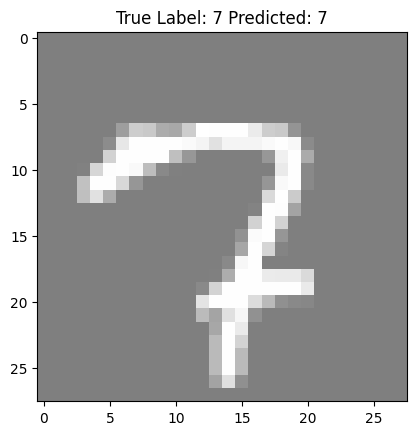

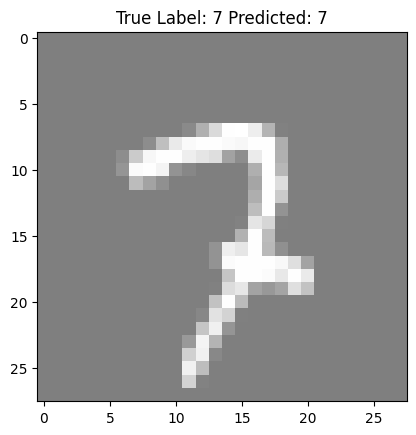

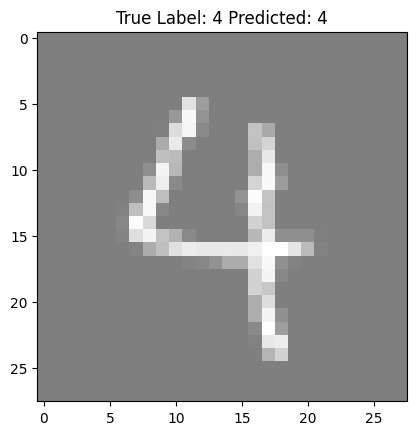

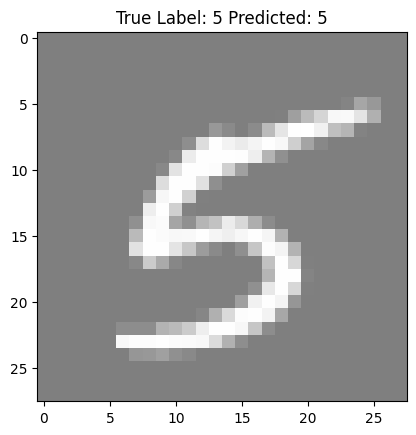

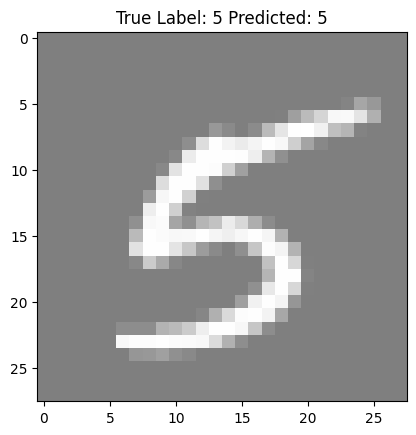

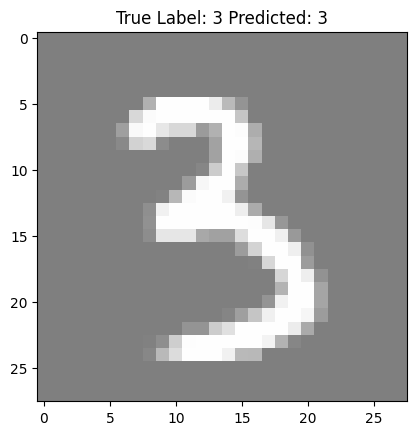

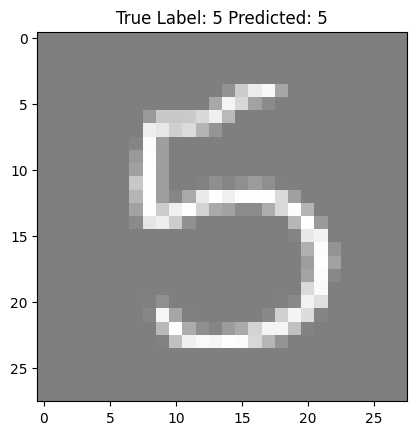

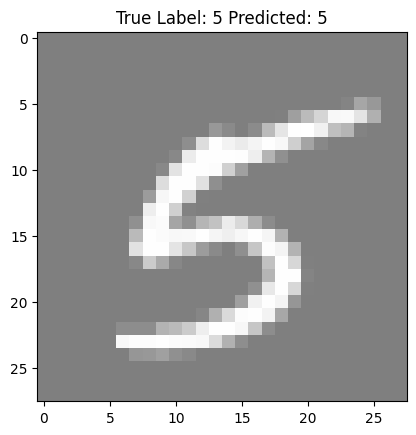

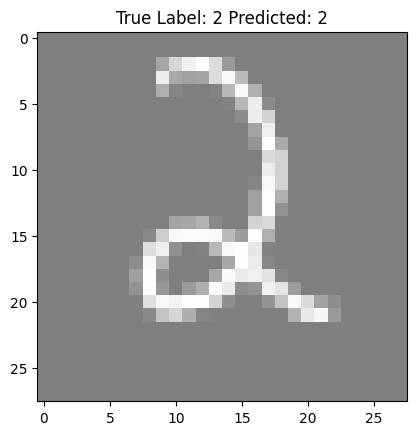

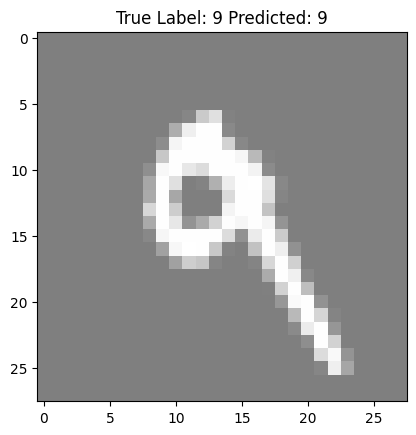

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Assuming `model` is your trained model, `test_loader` is the DataLoader for your test set.

# Function to display images and labels
def imshow(img, label, pred):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(f'True Label: {label} Predicted: {pred}')
    plt.show()

# Get random testing images and predict
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Print images, true labels, and model's predictions
modelMLP.eval()  # Set the model to evaluation mode
modelMLP.to(device) # Move model to the correct device
outputsMLP = modelMLP(images.to(device))

# Convert outputs to probabilities and predict class
_, predictedMLP = torch.max(outputsMLP, 1)

# Display random images with true and predicted labels
for i in range(10):  # Displaying 6 images
    index = np.random.randint(0, batch_size)  # Choose a random index
    imshow(torchvision.utils.make_grid(images[index]), labels[index].item(), predictedMLP[index].item())


#Convolutional Neural Network (CNN)

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Convolutional neural network (two convolutional layers)
class ConvNet(nn.Module):
    def __init__(self, num_classes=10):
        super(ConvNet, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.fc = nn.Linear(7*7*32, num_classes)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.reshape(out.size(0), -1)
        out = self.fc(out)
        return out

modelCNN = ConvNet(num_classes).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(modelCNN.parameters(), lr=learning_rate)

# Train the model
total_step = len(train_loader)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = modelCNN(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{total_step}], Loss: {loss.item():.4f}')

# Test the model
modelCNN.eval()  # eval mode (batchnorm uses moving mean/variance instead of mini-batch mean/variance)
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = modelCNN(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f'Accuracy of the network on the 10000 test images: {100 * correct / total} %')


Epoch [1/2], Step [100/938], Loss: 0.1683
Epoch [1/2], Step [200/938], Loss: 0.0645
Epoch [1/2], Step [300/938], Loss: 0.0267
Epoch [1/2], Step [400/938], Loss: 0.0268
Epoch [1/2], Step [500/938], Loss: 0.0784
Epoch [1/2], Step [600/938], Loss: 0.0509
Epoch [1/2], Step [700/938], Loss: 0.0635
Epoch [1/2], Step [800/938], Loss: 0.0499
Epoch [1/2], Step [900/938], Loss: 0.1125
Epoch [2/2], Step [100/938], Loss: 0.0461
Epoch [2/2], Step [200/938], Loss: 0.0820
Epoch [2/2], Step [300/938], Loss: 0.0076
Epoch [2/2], Step [400/938], Loss: 0.0377
Epoch [2/2], Step [500/938], Loss: 0.0271
Epoch [2/2], Step [600/938], Loss: 0.0031
Epoch [2/2], Step [700/938], Loss: 0.0206
Epoch [2/2], Step [800/938], Loss: 0.0525
Epoch [2/2], Step [900/938], Loss: 0.0219
Accuracy of the network on the 10000 test images: 98.43 %


#Results of CNN

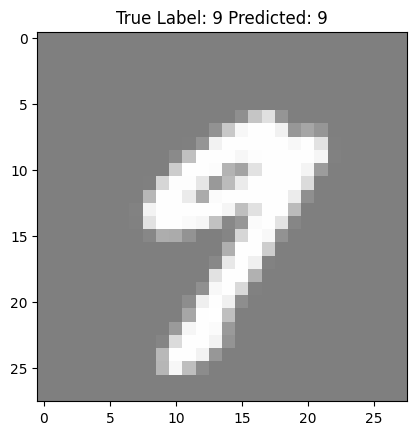

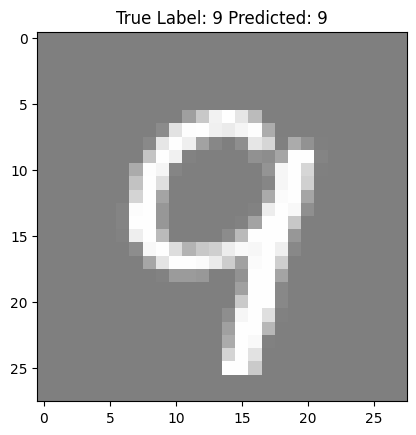

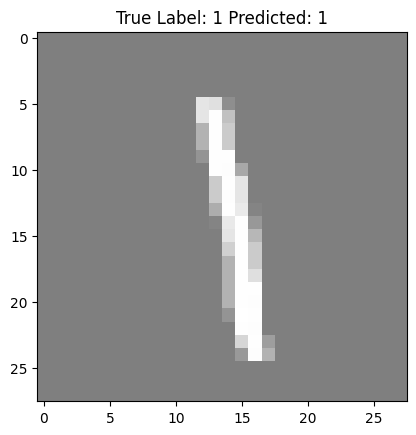

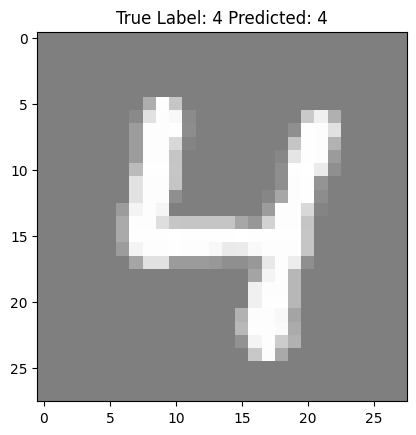

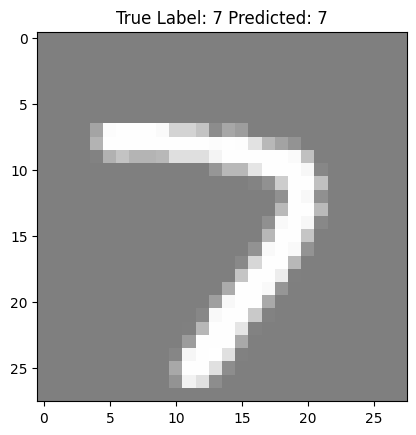

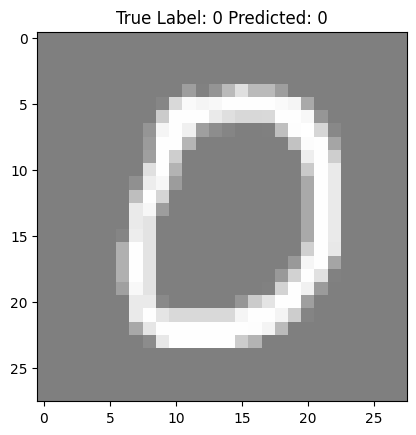

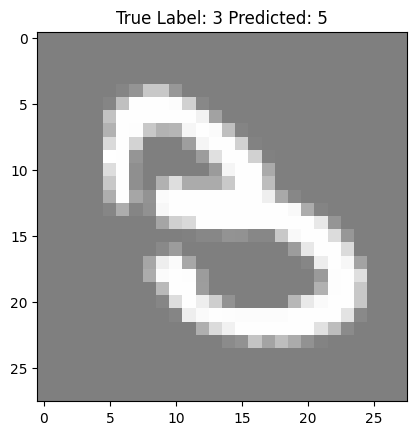

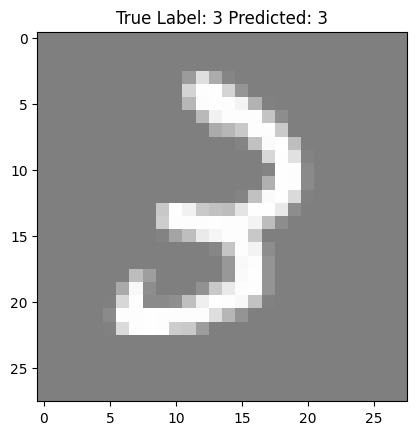

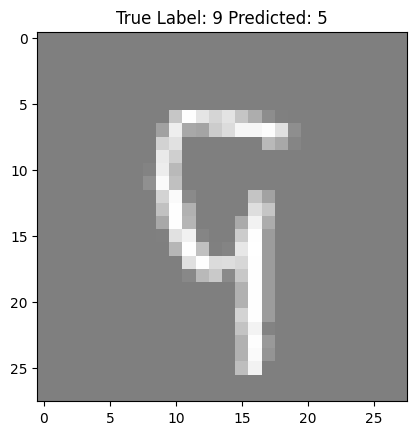

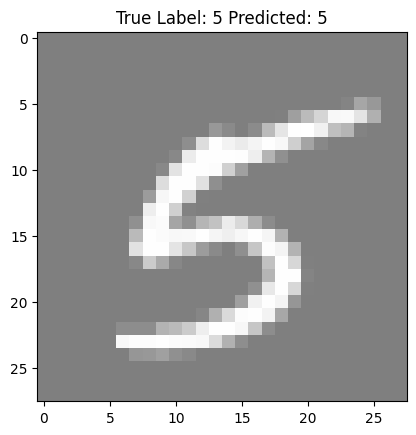

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision


# Assuming `model` is your trained model, `test_loader` is the DataLoader for your test set.

# Function to display images and labels
def imshow(img, label, pred):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(f'True Label: {label} Predicted: {pred}')
    plt.show()

def imshowboth(img, label, pred_mlp, pred_cnn):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(f'True Label: {label} Pred_mlp: {pred_mlp} Pred_cnn: {pred_cnn}')
    plt.show()

# Get random testing images and predict
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Print images, true labels, and model's predictions
modelCNN.eval()  # Set the model to evaluation mode
outputsCNN = modelCNN(images.to(device))

# Convert outputs to probabilities and predict class
_, predictedCNN = torch.max(outputsCNN, 1)

# Display random images with true and predicted labels
for i in range(10):  # Displaying 6 images
    index = np.random.randint(0, batch_size)  # Choose a random index
    imshow(torchvision.utils.make_grid(images[index]), labels[index].item(), predictedCNN[index].item())


#RESULTS of both in MLP and CNN

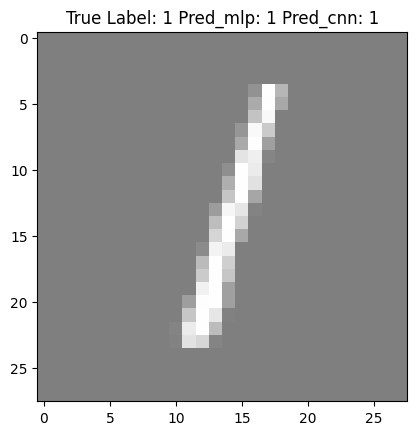

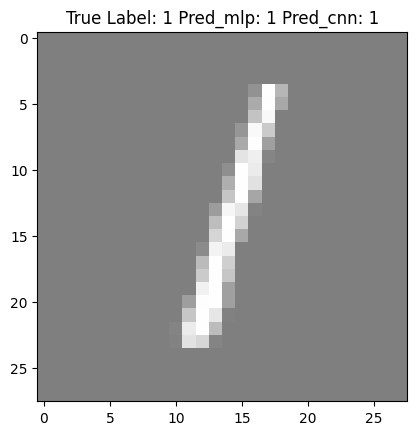

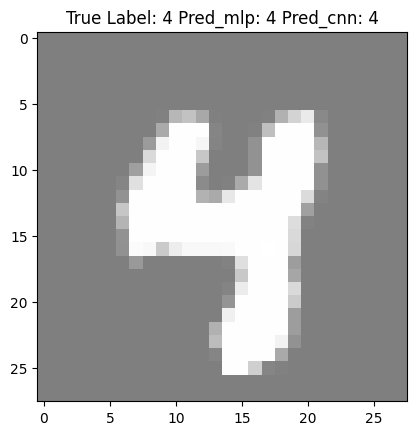

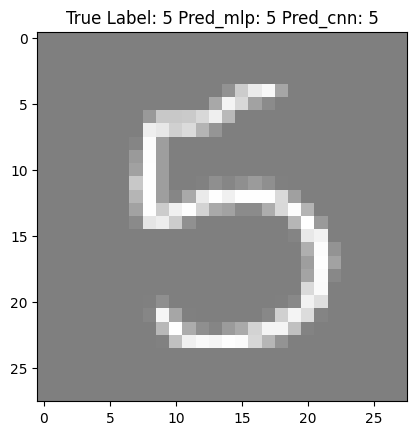

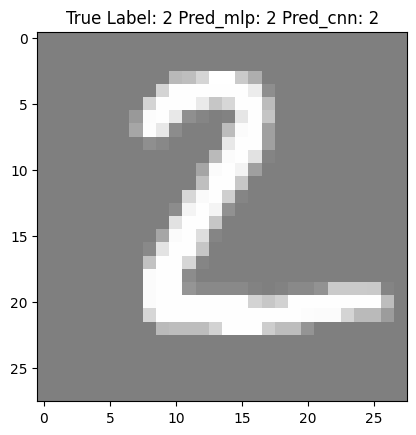

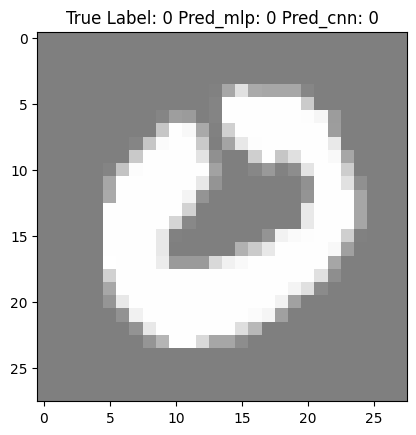

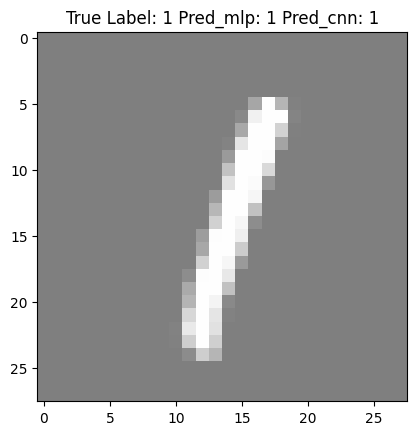

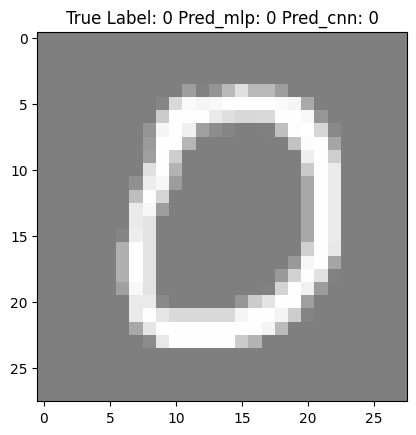

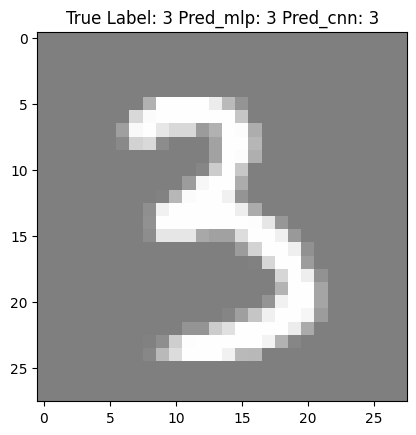

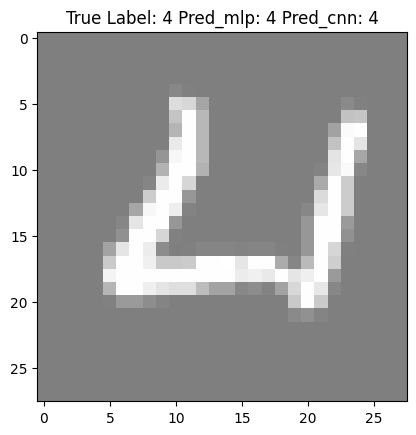

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision


# Assuming `model` is your trained model, `test_loader` is the DataLoader for your test set.

# Function to display images and labels
def imshow(img, label, pred):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(f'True Label: {label} Predicted: {pred}')
    plt.show()

def imshowboth(img, label, pred_mlp, pred_cnn):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(f'True Label: {label} Pred_mlp: {pred_mlp} Pred_cnn: {pred_cnn}')
    plt.show()

# Get random testing images and predict
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Print images, true labels, and model's predictions
modelCNN.eval()  # Set the model to evaluation mode
modelMLP.eval()  # Set the model to evaluation mode
outputsMLP = modelMLP(images.to(device))
outputsCNN = modelCNN(images.to(device))

# Convert outputs to probabilities and predict class
_, predictedMLP = torch.max(outputsMLP, 1)
_, predictedCNN = torch.max(outputsCNN, 1)

# Display random images with true and predicted labels
for i in range(10):  # Displaying 6 images
    index = np.random.randint(0, batch_size)  # Choose a random index
    imshowboth(torchvision.utils.make_grid(images[index]), labels[index].item(), predictedMLP[index].item(), predictedCNN[index].item())
    # imshow(torchvision.utils.make_grid(images[index]), labels[index].item(), predictedCNN[index].item())
